# **Movie Recommendation System**

-------------

## **Objective**
To build a movie recommendation system using cosine similarity.

## **Data Source**

https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Movies%20Recommendation.csv


## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## **Import Data**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Movies%20Recommendation.csv')

## **Describe Data**

In [4]:
df.head()

,Movie_ID,Movie_Title,Movie_Genre,Movie_Language,Movie_Budget,Movie_Popularity,Movie_Release_Date,Movie_Revenue,Movie_Runtime,Movie_Vote,...,Movie_Homepage,Movie_Keywords,Movie_Overview,Movie_Production_House,Movie_Production_Country,Movie_Spoken_Language,Movie_Tagline,Movie_Cast,Movie_Crew,Movie_Director
0,1,Four Rooms,Crime Comedy,en,4000000,22.876230,09-12-1995,4300000,98.0,6.5,...,NaN,hotel new year's eve witch bet hotel room,It's Ted the Bellhop's first night on the job....,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,"[{'name': 'Allison Anders', 'gender': 1, 'depa...",Allison Anders
1,2,Star Wars,Adventure Action Science Fiction,en,11000000,126.393695,25-05-1977,775398007,121.0,8.1,...,http://www.starwars.com/films/star-wars-episod...,android galaxy hermit death star lightsaber,Princess Leia is captured and held hostage by ...,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,"[{'name': 'George Lucas', 'gender': 2, 'depart...",George Lucas
2,3,Finding Nemo,Animation Family,en,94000000,85.688789,30-05-2003,940335536,100.0,7.6,...,http://movies.disney.com/finding-nemo,father son relationship harbor underwater fish...,"Nemo, an adventurous young clownfish, is unexp...","[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
3,4,Forrest Gump,Comedy Drama Romance,en,55000000,138.133331,06-07-1994,677945399,142.0,8.2,...,NaN,vietnam veteran hippie mentally disabled runni...,A man with a low IQ has accomplished great thi...,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,"[{'name': 'Alan Silvestri', 'gender': 2, 'depa...",Robert Zemeckis
4,5,American Beauty,Drama,en,15000000,80.878605,15-09-1999,356296601,122.0,7.9,...,http://www.dreamworks.com/ab/,male nudity female nudity adultery midlife cri...,"Lester Burnham, a depressed suburban father in...","[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Movie_ID                  4760 non-null   int64  
 1   Movie_Title               4760 non-null   object 
 2   Movie_Genre               4760 non-null   object 
 3   Movie_Language            4760 non-null   object 
 4   Movie_Budget              4760 non-null   int64  
 5   Movie_Popularity          4760 non-null   float64
 6   Movie_Release_Date        4760 non-null   object 
 7   Movie_Revenue             4760 non-null   int64  
 8   Movie_Runtime             4758 non-null   float64
 9   Movie_Vote                4760 non-null   float64
 10  Movie_Vote_Count          4760 non-null   int64  
 11  Movie_Homepage            1699 non-null   object 
 12  Movie_Keywords            4373 non-null   object 
 13  Movie_Overview            4757 non-null   object 
 14  Movie_Pr

In [6]:
df.shape

(4760, 21)

In [7]:
df.columns

Index(['Movie_ID', 'Movie_Title', 'Movie_Genre', 'Movie_Language',
       'Movie_Budget', 'Movie_Popularity', 'Movie_Release_Date',
       'Movie_Revenue', 'Movie_Runtime', 'Movie_Vote', 'Movie_Vote_Count',
       'Movie_Homepage', 'Movie_Keywords', 'Movie_Overview',
       'Movie_Production_House', 'Movie_Production_Country',
       'Movie_Spoken_Language', 'Movie_Tagline', 'Movie_Cast', 'Movie_Crew',
       'Movie_Director'],
      dtype='object')

## **Data Visualization**

<ipython-input-22-eae13bdff003>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis', legend=False)


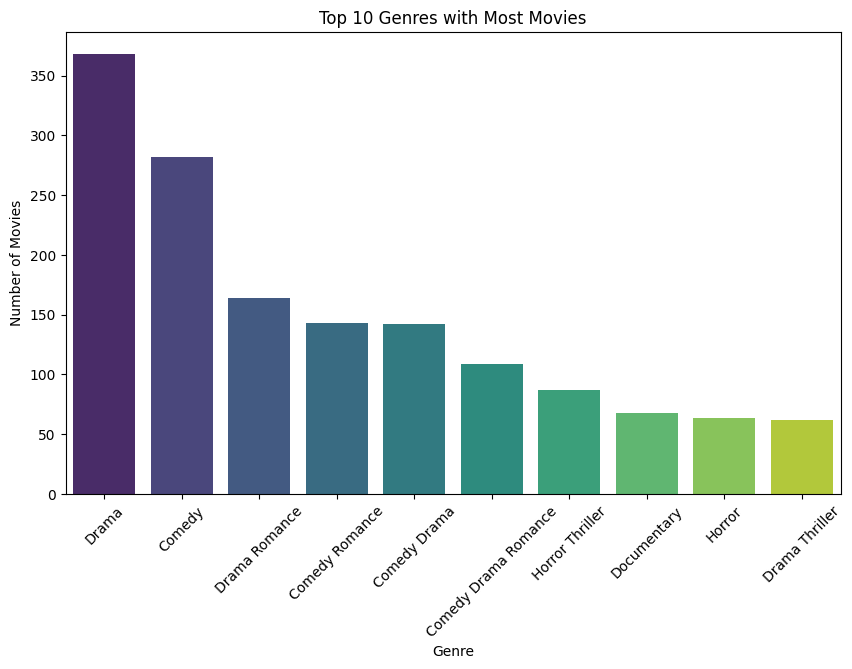

In [22]:
# Plotting the top 10 genres
top_genres = genre_counts.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis', legend=False)
plt.title('Top 10 Genres with Most Movies')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.xlabel('Genre')
plt.show()



## **Data Preprocessing**

In [8]:
df_features = df[['Movie_Genre', 'Movie_Keywords', 'Movie_Tagline', 'Movie_Cast', 'Movie_Director']].fillna('')

## **Define Target Variable (y) and Feature Variables (X)**

In [10]:
x = df_features['Movie_Genre'] + ' ' + df_features['Movie_Keywords'] + ' ' + df_features['Movie_Tagline'] + ' ' + df_features['Movie_Cast'] + ' ' + df_features['Movie_Director']

## **Train Test Split**

## **Modeling**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf = TfidfVectorizer()
x = Tfidf.fit_transform(x)

from sklearn.metrics.pairwise import cosine_similarity
similarity_score = cosine_similarity(x)


## **Model Evaluation**

In [15]:
favourite_movie = input('Enter your favorite movie name: ')
all_movies_title_list = df['Movie_Title'].tolist()

import difflib
Movie_Recommendation = difflib.get_close_matches(favourite_movie, all_movies_title_list)
close_match = Movie_Recommendation[0]
Index_of_close_match_Movie = df[df.Movie_Title == close_match]['Movie_ID'].values[0]

Recommendation_Score = list(enumerate(similarity_score[Index_of_close_match_Movie]))
sorted_similar_movies = sorted(Recommendation_Score, key=lambda x: x[1], reverse=True)


Enter your favorite movie name: avtaar


## **Prediction**

In [16]:
print('Top 30 Movies Suggested for you: \\n')
i = 1
for movie in sorted_similar_movies:
    index = movie[0]
    title_from_index = df[df.index == index]['Movie_Title'].values[0]
    if (i < 31):
        print(i, '.', title_from_index)
        i += 1


Top 30 Movies Suggested for you: \n
1 . Niagara
2 . Caravans
3 . My Week with Marilyn
4 . Brokeback Mountain
5 . Harry Brown
6 . Night of the Living Dead
7 . The Curse of Downers Grove
8 . The Boy Next Door
9 . Back to the Future
10 . The Juror
11 . Some Like It Hot
12 . Enough
13 . The Kentucky Fried Movie
14 . Eye for an Eye
15 . Welcome to the Sticks
16 . Alice Through the Looking Glass
17 . Superman III
18 . The Misfits
19 . Premium Rush
20 . Duel in the Sun
21 . Sabotage
22 . Small Soldiers
23 . All That Jazz
24 . Camping Sauvage
25 . The Raid
26 . Beyond the Black Rainbow
27 . To Kill a Mockingbird
28 . World Trade Center
29 . The Dark Knight Rises
30 . Tora! Tora! Tora!


## **Explaination**

**Cosine similarity is used to measure the similarity between two non-zero vectors. It is calculated as the cosine of the angle between two vectors in a multi-dimensional space. In this recommendation system, it helps to identify similar movies based on features like genre, keywords, tagline, etc.**